In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GRN_ROOT = './data'

In [3]:
GRN = pd.read_csv(f'{GRN_ROOT}/inferred_GRN.csv', index_col = 0)

In [4]:
GRN['Reg_name'] = np.where(GRN['Reg'] == -1, 'Inhibitory', 'Excitatory')

In [5]:
GRN

,TF,Gene,Reg,Reg_name
0,ADNP,A2M,-1.0,Inhibitory
1,ADNP2,A2M,1.0,Excitatory
2,AEBP1,A2M,-1.0,Inhibitory
4,AHR,A2M,-1.0,Inhibitory
6,AIRE,A2M,-1.0,Inhibitory
...,...,...,...,...
1057,ZNF92,ZZZ3,-1.0,Inhibitory
1061,ZSCAN16,ZZZ3,1.0,Excitatory
1064,ZSCAN21,ZZZ3,-1.0,Inhibitory
1065,ZSCAN22,ZZZ3,1.0,Excitatory


In [6]:
graph = nx.from_pandas_edgelist(GRN, source = 'TF', target='Gene', edge_attr='Reg_name', create_using = nx.DiGraph)

# GRN properties examinations

In [7]:
#get list of gene names that are TFs only, TGs only, and both
DATA_ROOT = '../../data'
network = pd.read_csv(f'{DATA_ROOT}/Full data files/network(full).tsv', sep='\t')
TFs = set(GRN['TF'])
TGs = set(GRN['Gene'])
TF_TGs = TFs & TGs
#mkae TFs set the TFs that are not also TGs
TFs = TFs - TF_TGs
TGs = TGs - TF_TGs
print(f'There are {len(TFs)} TFs and {len(TGs)} TGs. {len(TF_TGs)} TFs are also TGs')

There are 56 TFs and 14228 TGs. 1019 TFs are also TGs


In [8]:
in_degree_dict = {}
out_degree_dict = {}

for node in graph.nodes():
    in_degree_dict[node] = graph.in_degree(node)
    out_degree_dict[node] = graph.out_degree(node)

In [9]:
TF_in_degrees = {k: in_degree_dict[k] for k in TFs}
TF_out_degrees = {k: out_degree_dict[k] for k in TFs}

In [10]:
TG_in_degrees = {k: in_degree_dict[k] for k in TGs}
TG_out_degrees = {k: out_degree_dict[k] for k in TGs}

In [11]:
TF_TG_in_degrees = {k: in_degree_dict[k] for k in TF_TGs}
TF_TG_out_degrees = {k: out_degree_dict[k] for k in TF_TGs}

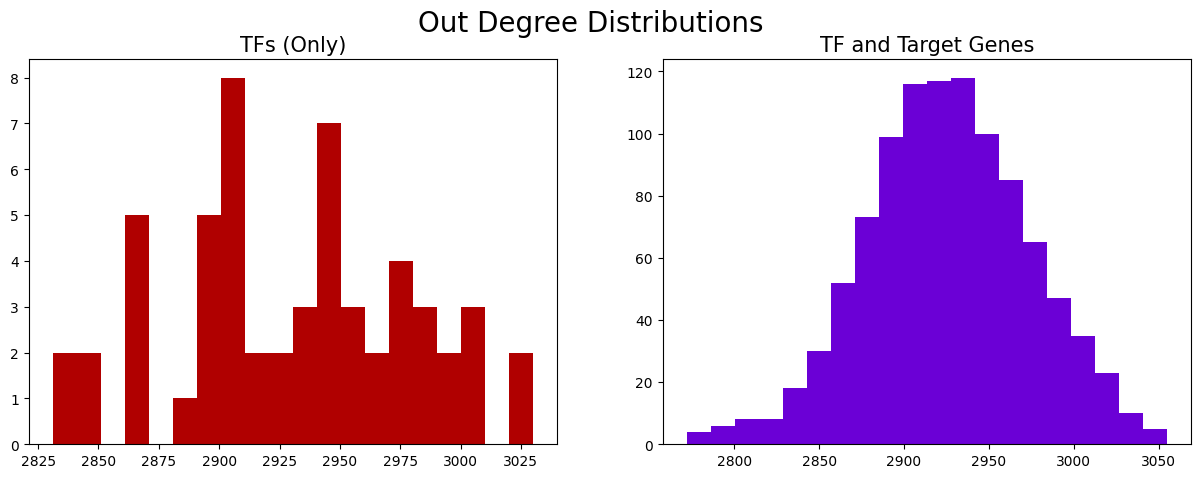

In [46]:
fig, ax = plt.subplots(ncols = 2, figsize = (15, 5))
ax[0].hist(TF_out_degrees.values(), bins = 20, color = '#b00000')
ax[0].set_title('TFs (Only)', fontsize = 15)
ax[1].hist(TF_TG_out_degrees.values(), bins = 20, color = '#6b00d6')
ax[1].set_title('TF and Target Genes', fontsize = 15)
fig.suptitle('Out Degree Distributions', fontsize = 20)
plt.show()

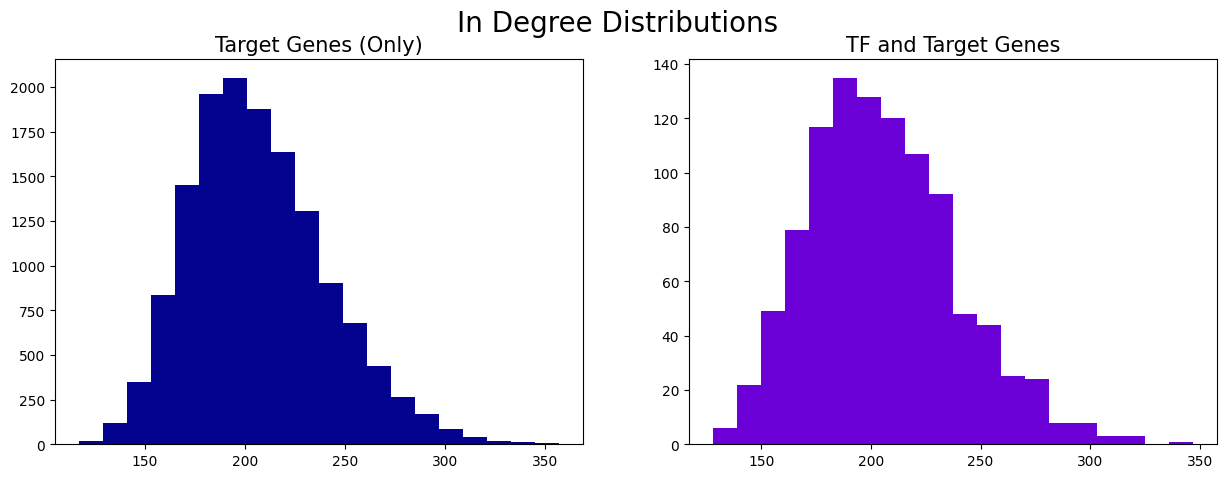

In [47]:
fig, ax = plt.subplots(ncols = 2, figsize = (15, 5))
ax[0].hist(TG_in_degrees.values(), bins = 20, color = '#03038f')
ax[0].set_title('Target Genes (Only)', fontsize = 15)
ax[1].hist(TF_TG_in_degrees.values(), bins = 20, color = '#6b00d6')
ax[1].set_title('TF and Target Genes', fontsize = 15)
fig.suptitle('In Degree Distributions', fontsize = 20)
plt.show()

In [23]:
degree_centralities = nx.degree_centrality(graph)
TF_TG_centralities = {k: degree_centralities[k] for k in TF_TGs}

In [38]:
TFTG_df = pd.DataFrame([TF_TG_in_degrees, TF_TG_out_degrees, TF_TG_centralities], index = ['in degree', 'out degree', 'Centrality']).T

Text(0.5, 1.0, 'TF-TG Connectedness')

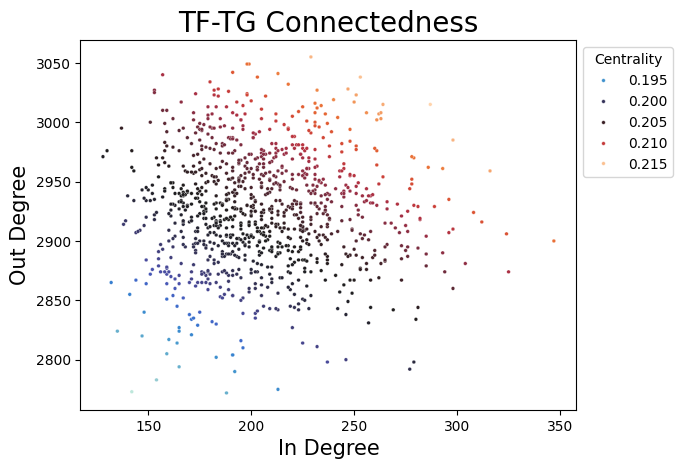

In [48]:
fig, ax = plt.subplots(1)
sns.scatterplot(TFTG_df, x = 'in degree', y = 'out degree', hue = 'Centrality', s = 7, palette = 'icefire')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel('Out Degree', fontsize = 15)
ax.set_xlabel('In Degree', fontsize = 15)
ax.set_title('TF-TG Connectedness', fontsize = 20)

In [ ]:
nx.betweenness_centrality(graph)

In [17]:
PIP4K2C_graph_df = GRN[GRN['Gene'] == 'PIP4K2C']
PIP4K2C_graph = nx.from_pandas_edgelist(PIP4K2C_graph_df, source = 'TF', target='Gene', edge_attr='Reg_name', create_using = nx.DiGraph)

In [18]:
reg_type = nx.get_edge_attributes(PIP4K2C_graph,'Reg_name').values()
reg_type

dict_values(['Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibi

In [19]:
#create a dictionary mapping reg type to colors
cmap = {
    'Inhibitory' : 'red',
    'Excitatory' : 'blue'
}

color_list = [cmap[reg_t] for reg_t in reg_type]

In [20]:
'PIP4K2C' in PIP4K2C_graph.nodes()

True

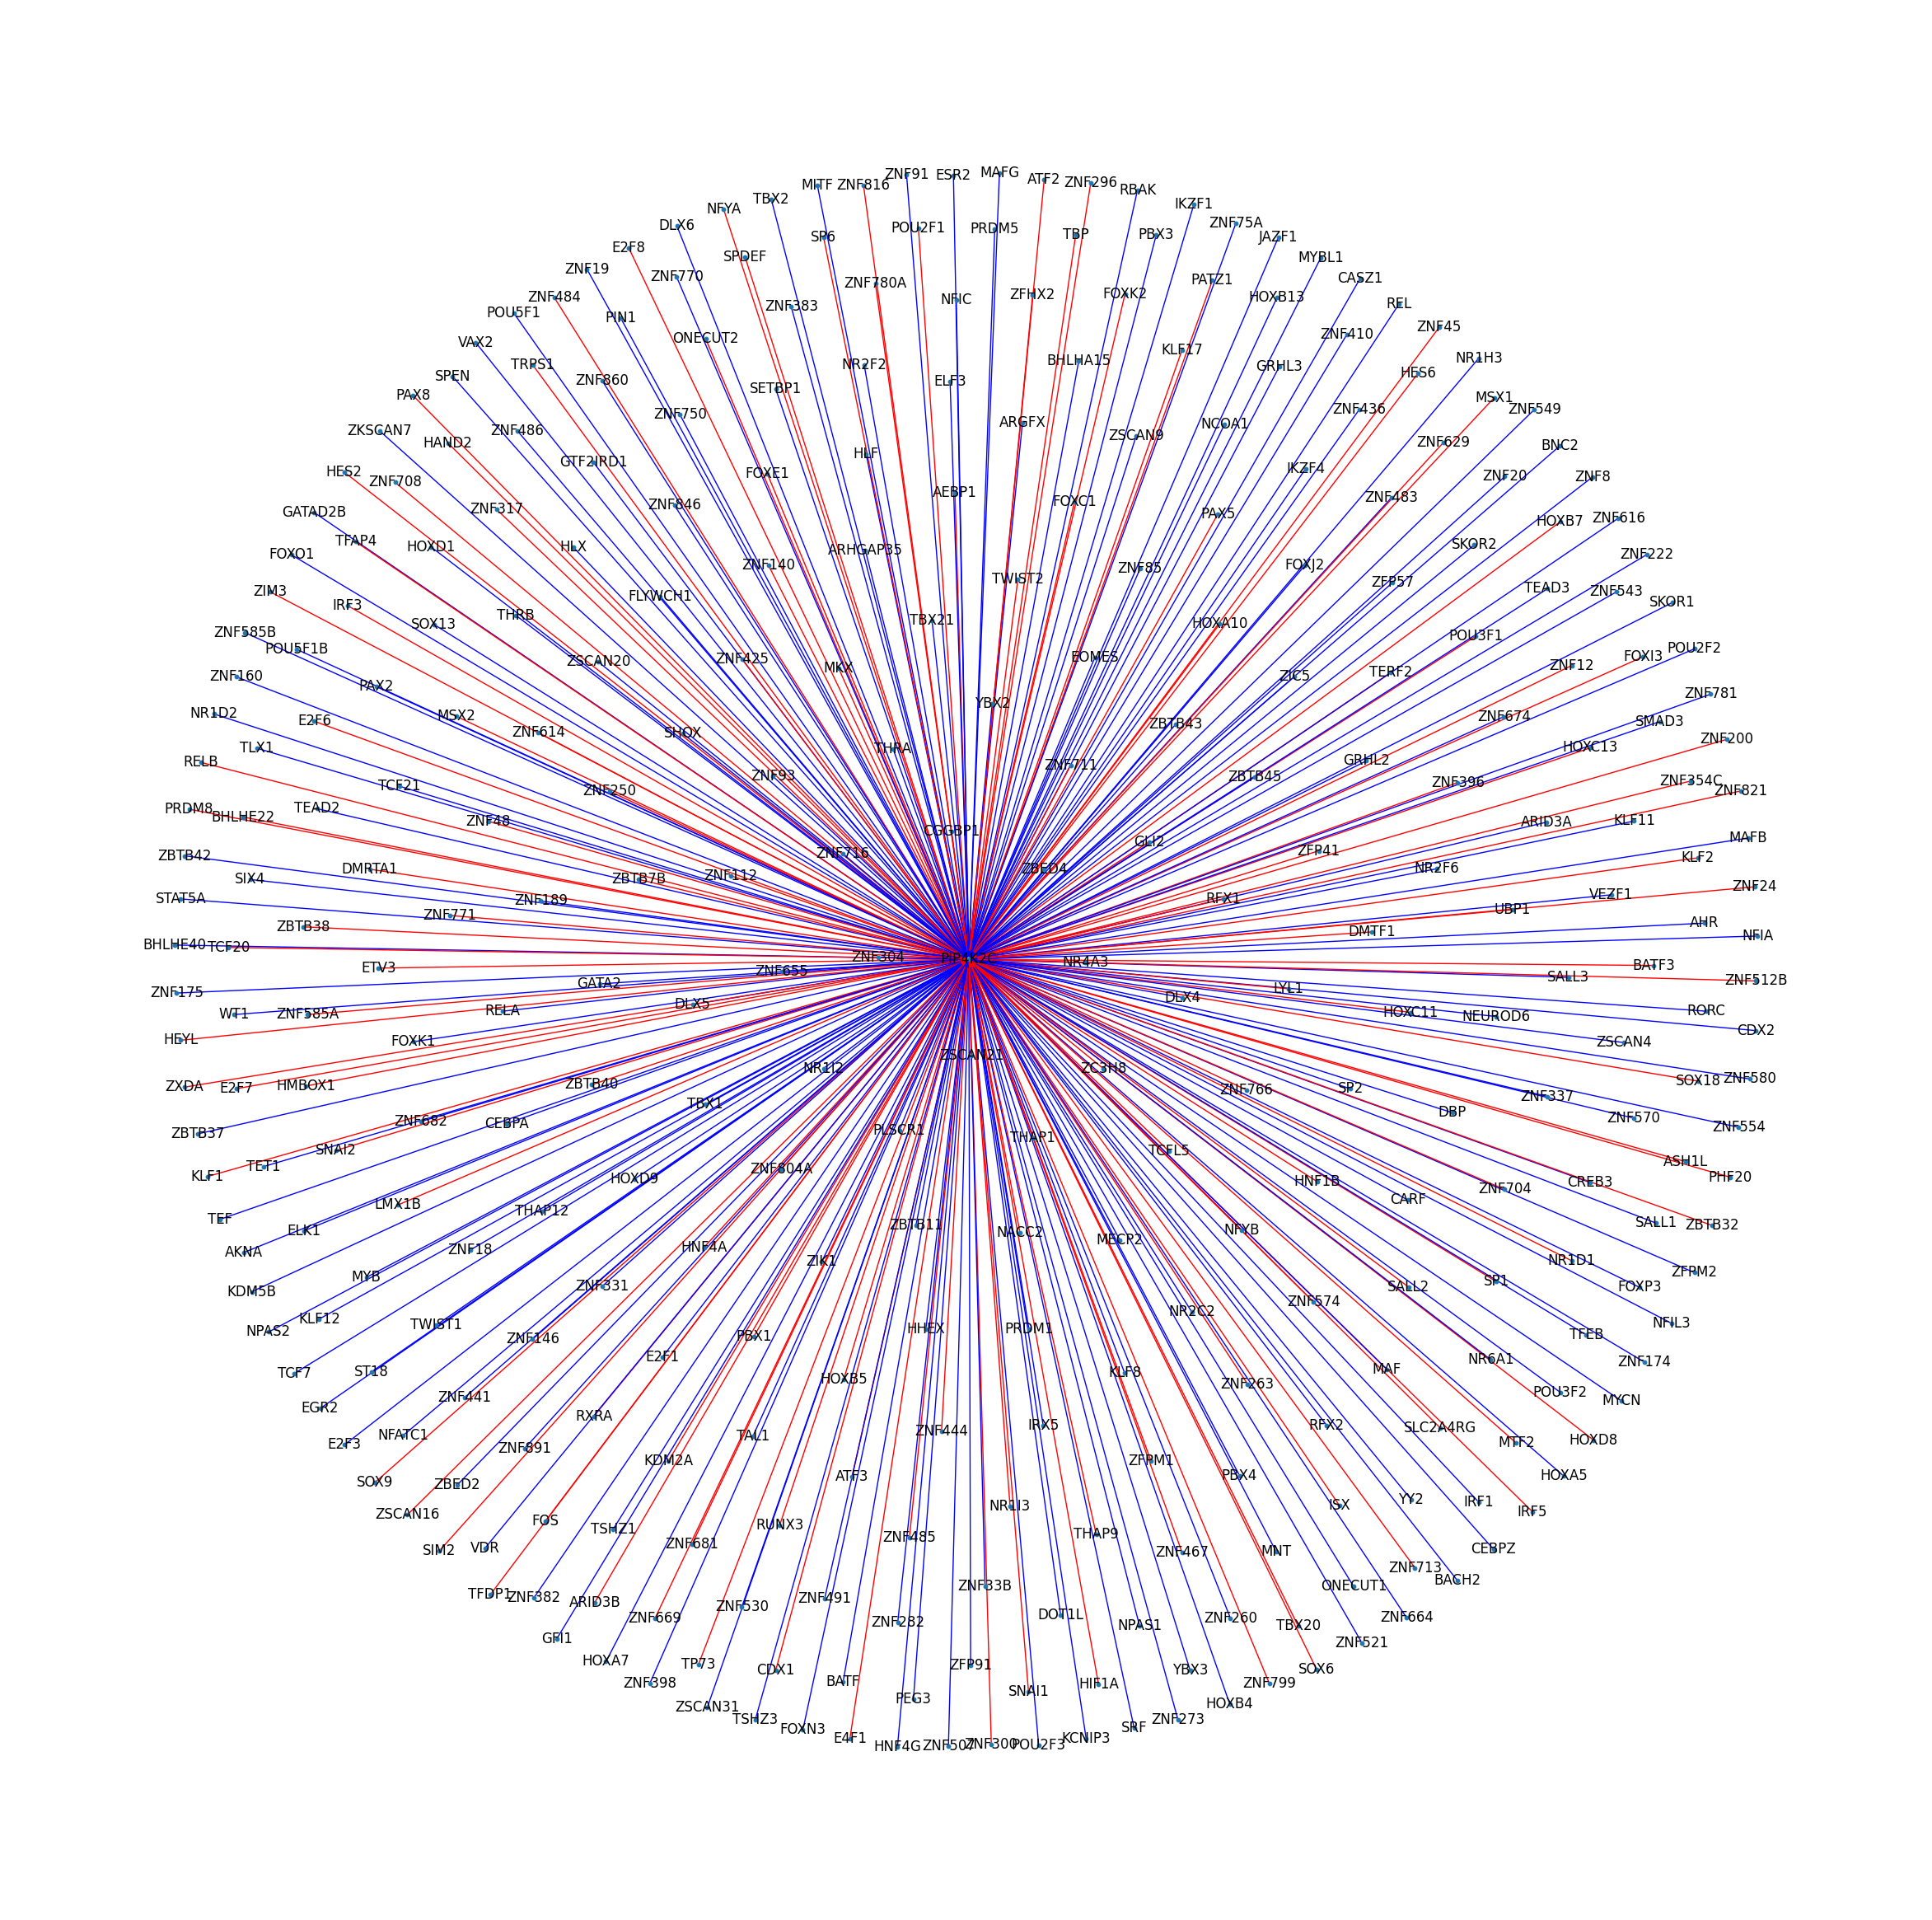

In [21]:
fig, ax = plt.subplots(figsize=(30,30))

layout = nx.arf_layout(PIP4K2C_graph)
nx.draw(PIP4K2C_graph,
        layout,
        edge_color= color_list,
        with_labels=True,
        node_size = 10)

In [22]:
len(PIP4K2C_graph.nodes())

352